In [1]:
print("MDPI Implementation Started")

MDPI Implementation Started


In [1]:
import pandas as pd

train = pd.read_csv("../data/composite/composite_train.csv")
test = pd.read_csv("../data/composite/composite_test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

C:\Users\thrup\AppData\Local\Temp\ipykernel_33064\2130592732.py:3: DtypeWarning: Columns (0: label, 1: Unnamed: 2, 2: Unnamed: 3, 3: Unnamed: 4, 4: Unnamed: 5, 5: Unnamed: 6, 6: Unnamed: 7, 7: Unnamed: 8, 8: Unnamed: 9, 9: Unnamed: 10, 10: Unnamed: 11, 11: Unnamed: 12, 12: Unnamed: 13, 13: Unnamed: 14, 14: Unnamed: 15, 15: Unnamed: 16, 16: Unnamed: 17, 17: Unnamed: 18, 18: Unnamed: 19, 19: Unnamed: 20, 20: Unnamed: 21, 21: Unnamed: 22, 22: Unnamed: 23, 23: Unnamed: 24, 24: Unnamed: 25, 25: Unnamed: 26, 26: Unnamed: 27, 27: Unnamed: 28, 28: Unnamed: 29, 29: Unnamed: 30, 30: Unnamed: 31, 31: Unnamed: 32, 32: Unnamed: 33, 33: Unnamed: 34, 34: Unnamed: 35, 35: Unnamed: 36, 36: Unnamed: 37, 37: Unnamed: 38, 38: Unnamed: 39, 39: Unnamed: 40, 40: Unnamed: 41, 41: Unnamed: 42, 42: Unnamed: 43, 43: Unnamed: 44, 44: Unnamed: 45, 45: Unnamed: 46, 46: Unnamed: 47, 47: Unnamed: 48, 48: Unnamed: 49, 49: Unnamed: 50, 50: Unnamed: 51, 51: Unnamed: 52, 52: Unnamed: 53, 53: Unnamed: 54, 54: Unnamed: 55,

Train Shape: (36759, 242)
Test Shape: (9189, 15)


In [2]:
print(train.shape)
print(test.shape)

(36759, 242)
(9189, 15)


In [3]:
print(train.columns.tolist()[:20])

['text', 'label', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19']


In [4]:
train = train[["text","label"]]
test = test[["text","label"]]

print(train.shape)
print(test.shape)

(36759, 2)
(9189, 2)


In [5]:
print(train["label"].unique())
print(test["label"].unique())

[1 0 '0' '1' nan
 ' please call 02 1301 and ask to be connected to Prosecutor . 013? 1301 yes? 1301 1301 yes Can I hang it here? I said 02. 02 1301 This is our center’s representative number now. Once we do that'
 ' KakaoTalk'
 " I did that What are there any overseas accounts abroad? There's no Citibank account? Citibank? yes Citibank has never made a statement Oh"
 " right? yes yes What if that photo is passed around to other people and then goes to a financial institution employee and opens a bank account? yes Isn't that a problem? It's a problem There is also a possibility that one more bank account has been opened"
 ' you can only receive the remaining amount excluding the amount borrowed from the insurance. I get about 100'
 " and the Financial Supervisory Service should also visit the Financial Supervisory Service. After today? Shouldn't we stop by with a gynecologist? Do you have a gynecologist and your husband returns to the company? I didn't return because I got half the afte

In [6]:
bad_rows = train[
    ~train["label"].isin(["0","1",0,1])
]

print("Bad Rows:", len(bad_rows))

Bad Rows: 16


In [7]:
train = train[train["label"].isin(["0","1",0,1])]
test = test[test["label"].isin(["0","1",0,1])]

print(train.shape)
print(test.shape)

(36743, 2)
(9187, 2)


In [8]:
train["label"] = train["label"].astype(int)
test["label"] = test["label"].astype(int)

print(train["label"].unique())
print(test["label"].unique())

[1 0]
[1 0]


In [9]:
print(train.head())
print(train["label"].value_counts())

                                                text  label
0  "Hello, this is the National Lottery Center. C...      1
1  'I am a traffic consultation assistant. I can ...      1
2  Sez, hows u & de arab boy? Hope u r all good g...      0
3  I like to travel domestically or international...      0
4  'Welcome, are there any products you would lik...      1
label
1    20761
0    15982
Name: count, dtype: int64


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train = vectorizer.fit_transform(train["text"])
X_test = vectorizer.transform(test["text"])

y_train = train["label"]
y_test = test["label"]

print(X_train.shape)
print(X_test.shape)

(36743, 10000)
(9187, 10000)


In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

print("Training Complete")

Training Complete


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

preds = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall   :", recall_score(y_test, preds))
print("F1 Score :", f1_score(y_test, preds))

print("\nClassification Report:")
print(classification_report(y_test, preds))

Accuracy : 0.9878088603461412
Precision: 0.9953198127925117
Recall   : 0.9830508474576272
F1 Score : 0.9891472868217054

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3995
           1       1.00      0.98      0.99      5192

    accuracy                           0.99      9187
   macro avg       0.99      0.99      0.99      9187
weighted avg       0.99      0.99      0.99      9187



In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

print("Tokenizer Loaded")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

c:\Users\thrup\OneDrive\Desktop\Int Proj\MDPI_Vishing\venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\thrup\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer Loaded


In [14]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train)
test_ds = Dataset.from_pandas(test)

In [15]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

print("Tokenization Complete")

Map:   0%|          | 0/36743 [00:00<?, ? examples/s]

Map:   0%|          | 0/9187 [00:00<?, ? examples/s]

Tokenization Complete


In [16]:
print(train_ds[0])

{'text': '"Hello, this is the National Lottery Center. Congratulations on winning this issue\'s jackpot, with a prize of up to 5 million rupees! Please confirm your personal information so that we can carry out the prize redemption process. ", "Don\'t worry, this is a formal award redeem process. We need to check your identity information to ensure that the bonus can be distributed safely to your account. What is your name and ID number? ", \' (The tone becomes a little impatient) We have informed you of the winning information on the phone, and you can call 114 to check our official number at any time. Now please provide your information as soon as possible, our system will be shut down soon. If it is not provided in time, it may affect your prize redeem! \', "Really? It\'s incredible! Why am I so lucky? However, do I need to confirm my personal information? Will there be any problem with this? ", "This sounds quite formal, but I\'ve also heard of some scam calls. Can you provide some

In [17]:
small_train = train_ds.select(range(5000))
small_test = test_ds.select(range(1000))

print(len(small_train))
print(len(small_test))

5000
1000


In [18]:
train_ds = train_ds.remove_columns(["text"])
test_ds = test_ds.remove_columns(["text"])

train_ds = train_ds.rename_column("label", "labels")
test_ds = test_ds.rename_column("label", "labels")

train_ds.set_format("torch")
test_ds.set_format("torch")

print(train_ds[0].keys())

dict_keys(['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'])


In [19]:
small_train = train_ds.select(range(5000))
small_test = test_ds.select(range(1000))

In [20]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print("Model Loaded")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Loaded


In [21]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="../outputs/distilbert",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100
)

In [22]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return accuracy.compute(
        predictions=preds,
        references=labels
    )

In [23]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    compute_metrics=compute_metrics
)

In [24]:
trainer.train()

c:\Users\thrup\OneDrive\Desktop\Int Proj\MDPI_Vishing\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.041971,0.027960,0.991000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=625, training_loss=0.08424627652168273, metrics={'train_runtime': 3657.4128, 'train_samples_per_second': 1.367, 'train_steps_per_second': 0.171, 'total_flos': 331168496640000.0, 'train_loss': 0.08424627652168273, 'epoch': 1.0})

In [25]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="../outputs/distilbert",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100
)

In [26]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return accuracy.compute(
        predictions=preds,
        references=labels
    )

In [27]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    compute_metrics=compute_metrics
)

In [28]:
trainer.train()

c:\Users\thrup\OneDrive\Desktop\Int Proj\MDPI_Vishing\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.038663,0.036258,0.994000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=625, training_loss=0.04058944587707519, metrics={'train_runtime': 5973.9734, 'train_samples_per_second': 0.837, 'train_steps_per_second': 0.105, 'total_flos': 331168496640000.0, 'train_loss': 0.04058944587707519, 'epoch': 1.0})

In [29]:
results = trainer.evaluate()

print(results)

c:\Users\thrup\OneDrive\Desktop\Int Proj\MDPI_Vishing\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
0.038663,0.036258,1,0.994000


{'eval_loss': 0.03625776618719101, 'eval_accuracy': 0.994}


In [30]:
print(train_ds[0].keys())

dict_keys(['labels', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'])


AUDIO BRANCH

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

In [5]:
audio_path = "../data/ravdess/Actor_01/03-01-01-01-01-01-01.wav"

In [6]:
import librosa

signal, sr = librosa.load(audio_path, sr=16000)

print("Signal Shape:", signal.shape)
print("Sampling Rate:", sr)

Signal Shape: (52853,)
Sampling Rate: 16000


In [7]:
signal, sr = librosa.load(audio_path, sr=16000)

print(signal.shape)
print(sr)

(52853,)
16000


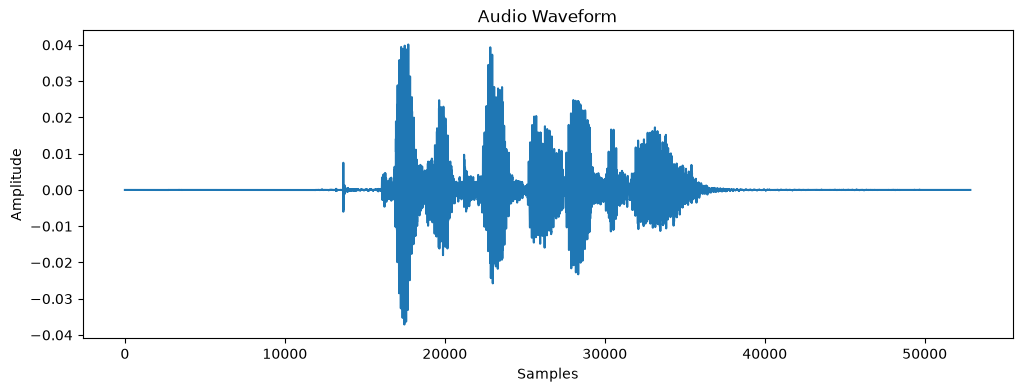

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(signal)
plt.title("Audio Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [9]:
mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=13
)

print("MFCC Shape:", mfcc.shape)

MFCC Shape: (13, 104)


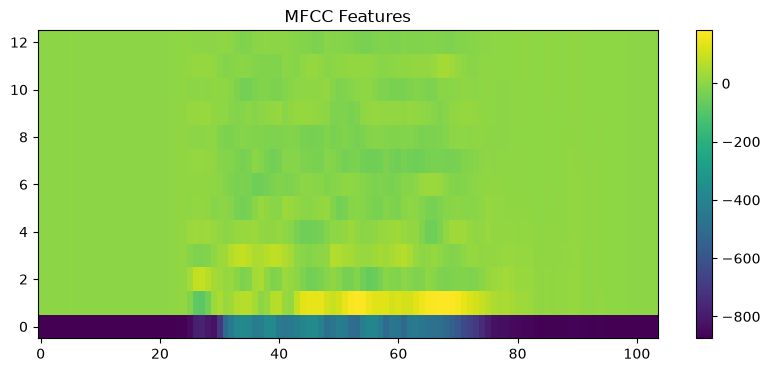

In [10]:
plt.figure(figsize=(10,4))
plt.imshow(mfcc, aspect="auto", origin="lower")
plt.colorbar()
plt.title("MFCC Features")
plt.show()

In [11]:
import numpy as np

mfcc_mean = np.mean(mfcc, axis=1)

print("MFCC Mean Shape:", mfcc_mean.shape)
print(mfcc_mean)

MFCC Mean Shape: (13,)
[-6.94231506e+02  5.00405540e+01  5.52266479e-01  1.45456295e+01
  3.44476175e+00 -2.46932721e+00 -3.98886704e+00 -1.05994053e+01
 -7.20489025e+00  1.95412970e+00 -4.29528236e+00  2.26853848e+00
 -5.36342907e+00]


In [12]:
pitch, magnitude = librosa.piptrack(
    y=signal,
    sr=sr
)

pitch_mean = pitch.mean()

print("Pitch Mean:", pitch_mean)

Pitch Mean: 91.73607


In [13]:
energy = np.mean(signal ** 2)

print("Energy:", energy)

Energy: 1.5975475e-05


In [14]:
zcr = librosa.feature.zero_crossing_rate(signal)

zcr_mean = zcr.mean()

print("ZCR Mean:", zcr_mean)

ZCR Mean: 0.3884699894831731


In [15]:
audio_features = np.concatenate([
    mfcc_mean,
    [pitch_mean],
    [energy],
    [zcr_mean]
])

print("Audio Feature Shape:", audio_features.shape)
print(audio_features)

Audio Feature Shape: (16,)
[-6.94231506e+02  5.00405540e+01  5.52266479e-01  1.45456295e+01
  3.44476175e+00 -2.46932721e+00 -3.98886704e+00 -1.05994053e+01
 -7.20489025e+00  1.95412970e+00 -4.29528236e+00  2.26853848e+00
 -5.36342907e+00  9.17360687e+01  1.59754745e-05  3.88469989e-01]


In [16]:
import os

wav_files = []

for root, dirs, files in os.walk("../data/ravdess"):
    for file in files:
        if file.endswith(".wav"):
            wav_files.append(
                os.path.join(root, file)
            )

print("Total WAV Files:", len(wav_files))

Total WAV Files: 2880


In [17]:
def extract_features(audio_path):

    signal, sr = librosa.load(
        audio_path,
        sr=16000
    )

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=13
    )

    mfcc_mean = np.mean(
        mfcc,
        axis=1
    )

    pitch, _ = librosa.piptrack(
        y=signal,
        sr=sr
    )

    pitch_mean = pitch.mean()

    energy = np.mean(
        signal ** 2
    )

    zcr = librosa.feature.zero_crossing_rate(
        signal
    )

    zcr_mean = zcr.mean()

    features = np.concatenate([
        mfcc_mean,
        [pitch_mean],
        [energy],
        [zcr_mean]
    ])

    return features

In [18]:
test_features = extract_features(
    wav_files[0]
)

print(test_features.shape)

(16,)


In [19]:
all_features = []

for file in wav_files:

    feat = extract_features(file)

    all_features.append(feat)

print("Done")
print(len(all_features))

Done
2880


In [20]:
import pandas as pd

audio_df = pd.DataFrame(
    all_features
)

print(audio_df.shape)

audio_df.head()

(2880, 16)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-694.231506,50.040554,0.552266,14.545630,3.444762,-2.469327,-3.988867,-10.599405,-7.204890,1.954130,-4.295282,2.268538,-5.363429,91.736069,0.000016,0.388470
1,-683.919617,49.147438,-1.772322,19.475557,1.976955,-0.559064,-4.736005,-12.186052,-5.475022,2.451120,-4.199459,1.815230,-5.239035,80.306305,0.000018,0.393392
2,-678.079041,51.527714,-0.038087,14.368165,0.833891,-0.185412,-6.124986,-10.725263,-7.614190,1.432122,-3.867249,2.219019,-5.851530,89.296898,0.000026,0.411479
3,-674.439636,50.828194,1.724960,14.461126,3.074210,1.751095,-7.570892,-11.271994,-7.132560,2.001614,-2.714117,0.932739,-4.972868,80.914185,0.000024,0.400679
4,-709.882812,56.299438,2.662531,16.805483,3.564945,-0.874765,-5.644424,-8.770026,-8.923411,2.069468,-4.683158,1.203360,-5.316927,97.313065,0.000009,0.376575


In [21]:
print(audio_df.shape)

(2880, 16)


In [23]:
print(wav_files[10])

../data/ravdess\Actor_01\03-01-02-02-02-01-01.wav


In [24]:
labels = []

for file in wav_files:

    filename = file.split("\\")[-1]

    emotion = int(
        filename.split("-")[2]
    )

    labels.append(emotion)

print(labels[:10])

[1, 1, 1, 1, 2, 2, 2, 2, 2, 2]


In [25]:
audio_df["label"] = labels

audio_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,label
0,-694.231506,50.040554,0.552266,14.545630,3.444762,-2.469327,-3.988867,-10.599405,-7.204890,1.954130,-4.295282,2.268538,-5.363429,91.736069,0.000016,0.388470,1
1,-683.919617,49.147438,-1.772322,19.475557,1.976955,-0.559064,-4.736005,-12.186052,-5.475022,2.451120,-4.199459,1.815230,-5.239035,80.306305,0.000018,0.393392,1
2,-678.079041,51.527714,-0.038087,14.368165,0.833891,-0.185412,-6.124986,-10.725263,-7.614190,1.432122,-3.867249,2.219019,-5.851530,89.296898,0.000026,0.411479,1
3,-674.439636,50.828194,1.724960,14.461126,3.074210,1.751095,-7.570892,-11.271994,-7.132560,2.001614,-2.714117,0.932739,-4.972868,80.914185,0.000024,0.400679,1
4,-709.882812,56.299438,2.662531,16.805483,3.564945,-0.874765,-5.644424,-8.770026,-8.923411,2.069468,-4.683158,1.203360,-5.316927,97.313065,0.000009,0.376575,2


In [26]:
print(
    audio_df["label"].value_counts()
)

label
2    384
3    384
4    384
5    384
6    384
7    384
8    384
1    192
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

X = audio_df.drop(
    columns=["label"]
)

y = audio_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2304, 16)
(576, 16)


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

print("Training Complete")

Training Complete


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

print("Training Complete")

Training Complete


In [30]:
from sklearn.metrics import accuracy_score

preds = rf.predict(X_test)

acc = accuracy_score(
    y_test,
    preds
)

print("Accuracy:", acc)

Accuracy: 0.9201388888888888


In [31]:
audio_df["label"].value_counts()

label
2    384
3    384
4    384
5    384
6    384
7    384
8    384
1    192
Name: count, dtype: int64

In [34]:
import pandas as pd

train = pd.read_csv("../data/composite/composite_train.csv")
test = pd.read_csv("../data/composite/composite_test.csv")

print(train.shape)
print(test.shape)

C:\Users\thrup\AppData\Local\Temp\ipykernel_5904\3581766662.py:3: DtypeWarning: Columns (0: label, 1: Unnamed: 2, 2: Unnamed: 3, 3: Unnamed: 4, 4: Unnamed: 5, 5: Unnamed: 6, 6: Unnamed: 7, 7: Unnamed: 8, 8: Unnamed: 9, 9: Unnamed: 10, 10: Unnamed: 11, 11: Unnamed: 12, 12: Unnamed: 13, 13: Unnamed: 14, 14: Unnamed: 15, 15: Unnamed: 16, 16: Unnamed: 17, 17: Unnamed: 18, 18: Unnamed: 19, 19: Unnamed: 20, 20: Unnamed: 21, 21: Unnamed: 22, 22: Unnamed: 23, 23: Unnamed: 24, 24: Unnamed: 25, 25: Unnamed: 26, 26: Unnamed: 27, 27: Unnamed: 28, 28: Unnamed: 29, 29: Unnamed: 30, 30: Unnamed: 31, 31: Unnamed: 32, 32: Unnamed: 33, 33: Unnamed: 34, 34: Unnamed: 35, 35: Unnamed: 36, 36: Unnamed: 37, 37: Unnamed: 38, 38: Unnamed: 39, 39: Unnamed: 40, 40: Unnamed: 41, 41: Unnamed: 42, 42: Unnamed: 43, 43: Unnamed: 44, 44: Unnamed: 45, 45: Unnamed: 46, 46: Unnamed: 47, 47: Unnamed: 48, 48: Unnamed: 49, 49: Unnamed: 50, 50: Unnamed: 51, 51: Unnamed: 52, 52: Unnamed: 53, 53: Unnamed: 54, 54: Unnamed: 55, 

(36759, 242)
(9189, 15)


In [35]:
train = train.dropna(subset=["label"])
test = test.dropna(subset=["label"])

train = train[train["label"].isin(["0","1",0,1])]
test = test[test["label"].isin(["0","1",0,1])]

train["label"] = train["label"].astype(int)
test["label"] = test["label"].astype(int)

In [36]:
print(train.shape)
print(test.shape)

(36743, 242)
(9187, 15)


In [37]:
audio_df.to_csv(
    "../outputs/audio_features.csv",
    index=False
)

In [38]:
import joblib

joblib.dump(
    rf,
    "../models/audio_rf.pkl"
)

['../models/audio_rf.pkl']

In [39]:
import pandas as pd

train = pd.read_csv("../data/composite/composite_train.csv")
test = pd.read_csv("../data/composite/composite_test.csv")

print(train.shape)
print(test.shape)

C:\Users\thrup\AppData\Local\Temp\ipykernel_5904\3581766662.py:3: DtypeWarning: Columns (0: label, 1: Unnamed: 2, 2: Unnamed: 3, 3: Unnamed: 4, 4: Unnamed: 5, 5: Unnamed: 6, 6: Unnamed: 7, 7: Unnamed: 8, 8: Unnamed: 9, 9: Unnamed: 10, 10: Unnamed: 11, 11: Unnamed: 12, 12: Unnamed: 13, 13: Unnamed: 14, 14: Unnamed: 15, 15: Unnamed: 16, 16: Unnamed: 17, 17: Unnamed: 18, 18: Unnamed: 19, 19: Unnamed: 20, 20: Unnamed: 21, 21: Unnamed: 22, 22: Unnamed: 23, 23: Unnamed: 24, 24: Unnamed: 25, 25: Unnamed: 26, 26: Unnamed: 27, 27: Unnamed: 28, 28: Unnamed: 29, 29: Unnamed: 30, 30: Unnamed: 31, 31: Unnamed: 32, 32: Unnamed: 33, 33: Unnamed: 34, 34: Unnamed: 35, 35: Unnamed: 36, 36: Unnamed: 37, 37: Unnamed: 38, 38: Unnamed: 39, 39: Unnamed: 40, 40: Unnamed: 41, 41: Unnamed: 42, 42: Unnamed: 43, 43: Unnamed: 44, 44: Unnamed: 45, 45: Unnamed: 46, 46: Unnamed: 47, 47: Unnamed: 48, 48: Unnamed: 49, 49: Unnamed: 50, 50: Unnamed: 51, 51: Unnamed: 52, 52: Unnamed: 53, 53: Unnamed: 54, 54: Unnamed: 55, 

(36759, 242)
(9189, 15)


In [40]:
train = train.dropna(subset=["label"])
test = test.dropna(subset=["label"])

train = train[
    train["label"].isin(["0","1",0,1])
]

test = test[
    test["label"].isin(["0","1",0,1])
]

train["label"] = train["label"].astype(int)
test["label"] = test["label"].astype(int)

print(train.shape)
print(test.shape)

(36743, 242)
(9187, 15)


In [41]:
small_train = train.sample(
    n=5000,
    random_state=42
)

small_test = test.sample(
    n=1000,
    random_state=42
)

print(small_train.shape)
print(small_test.shape)

(5000, 242)
(1000, 15)


In [42]:
from datasets import Dataset

train_ds = Dataset.from_pandas(
    small_train
)

test_ds = Dataset.from_pandas(
    small_test
)

print(train_ds)

Dataset({
    features: ['text', 'label', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'Unnamed: 64', 'Unnamed: 65', 'Unnam

In [43]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

print("Tokenizer Loaded")

Tokenizer Loaded


In [44]:
def tokenize(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [45]:
train_ds = train_ds.map(
    tokenize,
    batched=True
)

test_ds = test_ds.map(
    tokenize,
    batched=True
)

print("Tokenization Complete")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenization Complete


In [67]:
print(train_ds)

Dataset({
    features: ['text', 'label', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'Unnamed: 64', 'Unnamed: 65', 'Unnam

In [68]:
print(train.columns.tolist())

['text', 'label']


In [70]:
small_train = train.sample(
    n=5000,
    random_state=42
)

small_test = test.sample(
    n=1000,
    random_state=42
)

In [71]:
from datasets import Dataset

train_ds = Dataset.from_pandas(
    small_train,
    preserve_index=False
)

test_ds = Dataset.from_pandas(
    small_test,
    preserve_index=False
)

In [72]:
print(train_ds.column_names)

['text', 'label']


In [73]:
train_ds = train_ds.map(
    tokenize,
    batched=True
)

test_ds = test_ds.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [74]:
print(train_ds.column_names)

['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


In [75]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print("Model Loaded")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Loaded


In [76]:
train_ds.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

test_ds.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

In [77]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="../outputs/distilbert",

    num_train_epochs=1,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_steps=100,

    report_to="none"
)

In [78]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return accuracy.compute(
        predictions=predictions,
        references=labels
    )

In [79]:
from transformers import Trainer

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_ds,

    eval_dataset=test_ds,

    compute_metrics=compute_metrics
)

print("Trainer Ready")

Trainer Ready


In [ ]:
trainer.train()

c:\Users\thrup\OneDrive\Desktop\Int Proj\MDPI_Vishing\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


In [ ]:
import torch

print(torch.cuda.is_available())